In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load Dataset
# Ensure the filename matches your local file path
df =pd.read_excel('glass.xlsx',sheet_name='glass')


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

--- Summary Statistics ---
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.5111

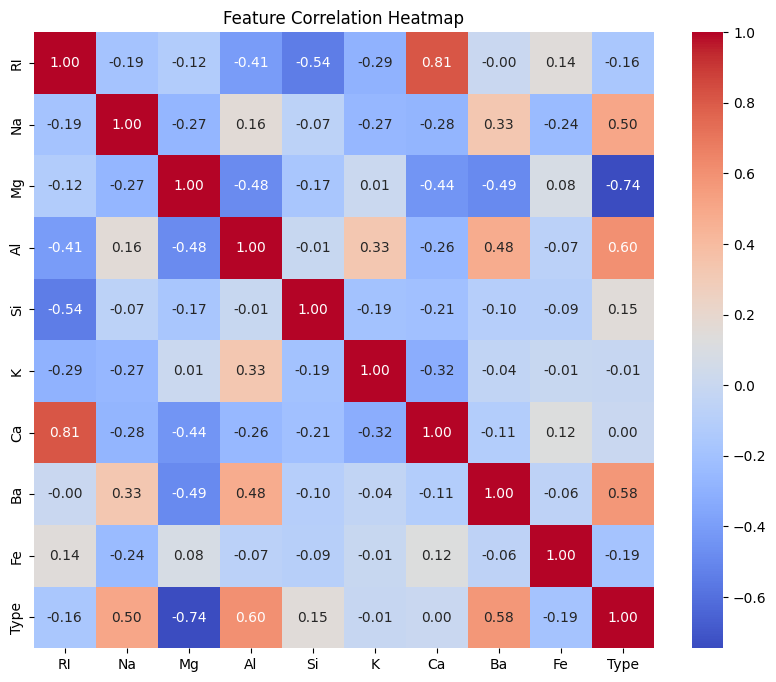

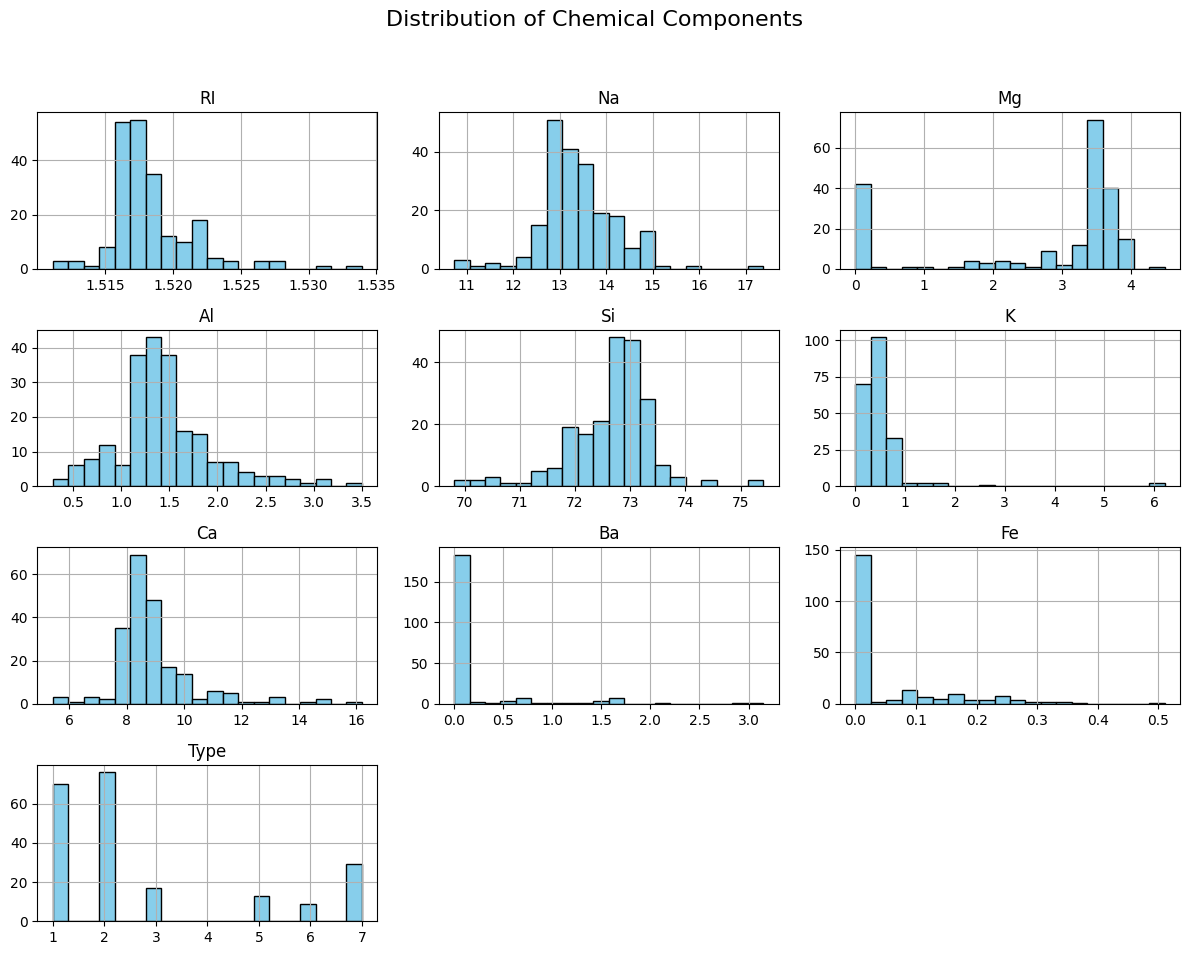

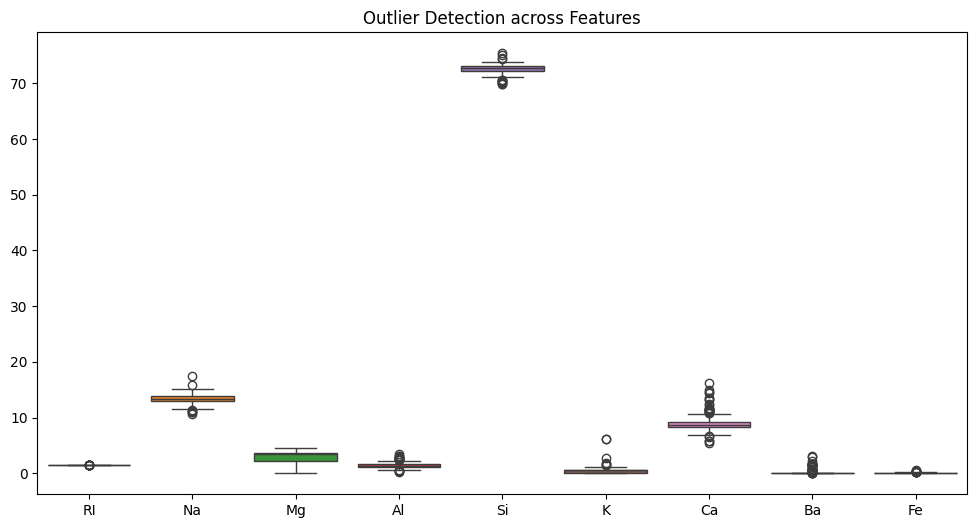

In [25]:

# --- SECTION 1: Exploratory Data Analysis (EDA) ---
print("--- Dataset Information ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Class Distribution (Target: Type) ---")
print(df['Type'].value_counts())

# --- SECTION 2: Data Visualization ---
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Histograms for all features
df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Chemical Components', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop('Type', axis=1))
plt.title('Outlier Detection across Features')
plt.show()


In [26]:

# --- SECTION 3: Data Preprocessing ---
# 1. Handling Imbalance: Manual Oversampling
# Since the 'Type' classes are unequal, we resample minority classes to match the majority size.
max_class_size = df['Type'].value_counts().max()
df_list = []
for type_label, group in df.groupby('Type'):
    df_list.append(group.sample(max_class_size, replace=True, random_state=42))
df_balanced = pd.concat(df_list).sample(frac=1).reset_index(drop=True)

X = df_balanced.drop('Type', axis=1)
y = df_balanced['Type']

# 2. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- SECTION 4: Random Forest Implementation ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))



--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           1       0.86      0.86      0.86        14
           2       0.82      0.82      0.82        17
           3       0.94      0.94      0.94        18
           5       0.94      1.00      0.97        15
           6       1.00      1.00      1.00        13
           7       1.00      0.93      0.97        15

    accuracy                           0.92        92
   macro avg       0.93      0.93      0.93        92
weighted avg       0.92      0.92      0.92        92



In [27]:
# --- SECTION 5: Bagging and Boosting Comparison ---
# Bagging Classifier
bagging = BaggingClassifier(n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

# Boosting Classifier (Gradient Boosting)
boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
y_pred_boost = boosting.predict(X_test)

print("\n--- Accuracy Comparison ---")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Bagging Accuracy:       {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"Boosting Accuracy:      {accuracy_score(y_test, y_pred_boost):.4f}")


--- Accuracy Comparison ---
Random Forest Accuracy: 0.9239
Bagging Accuracy:       0.9239
Boosting Accuracy:      0.9565



Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

1. Bagging and Boosting: Concepts and Differences
Ensemble methods combine multiple weak learners (usually Decision Trees) to create one strong, robust model.

Bagging (Bootstrap Aggregating)

Bagging works by creating multiple versions of the dataset using bootstrapping (sampling with replacement). A separate model is trained on each version in parallel, and their results are averaged (for regression) or voted upon (for classification).



* Primary Goal: To reduce variance (prevent overfitting).

* Example: Random Forest, where each tree is independent.



Boosting

Boosting works sequentially. Each new model attempts to correct the errors made by the previous ones. It gives more weight to the data points that were misclassified in the earlier rounds.




* Primary Goal: To reduce bias (improve accuracy and model fit).


*  Example: Gradient Boosting, AdaBoost, and XGBoost.




2. Handling Imbalance in Data

The Glass dataset is a prime example of imbalanced data, where some glass types (like Type 1 and 2) have many more samples than others. If not handled, the model will simply "guess" the majority class most of the time.

A. Resampling Techniques
Oversampling: Replicating instances of the minority class or creating synthetic ones until the classes are equal. SMOTE (Synthetic Minority Over-sampling Technique) is a popular method that creates new samples by interpolating between existing ones.

Undersampling: Removing instances from the majority class. This is usually only recommended if you have a massive dataset, as it discards valuable information.

B. Algorithmic Adjustments
Class Weights: Most libraries (like scikit-learn) allow you to set a class_weight='balanced' parameter. This tells the model to penalize mistakes on the minority class more heavily than on the majority class.

C. Using the Right Metrics
Accuracy is misleading for imbalanced data. Instead, focus on:

Precision: How many of the predicted positives were actually positive?

Recall: How many of the actual positives did the model catch?

F1-Score: The harmonic mean of Precision and Recall.